# This Notebook tests all gradients used in code and theory in the paper "Local Learning Rules for Out-of-Equilibrium Physical Generative Models"

In [1]:
import sys
sys.path.append("..")

import jax
from jax import flatten_util, vmap, grad
import jax.numpy as jnp
import jax.random as jr
import os
import matplotlib.pyplot as plt
from physical_diffusion_fns.helper_fns import sample_gaussian_mixture
from physical_diffusion_fns.learning_fns import CD1_gradient, setup_score_matching_LOSS_per_batch, setup_force_matching_GRADIENT_per_batch_using_AD, setup_force_matching_LOSS_and_GRADIENT_per_batch_analytical
from physical_diffusion_fns.plotting_fns import plot_energy_and_distributions, visualize_connectivity
from physical_diffusion_fns.network_fns import setup_energy_fn, setup_duffing_network_analytical_derivatives
jax.config.update("jax_enable_x64", True)


# Import memory-efficient versions
from physical_diffusion_fns.learning_fns_memory_efficient import (
    setup_score_matching_kbT_loss_minimal_memory
)
from physical_diffusion_fns.network_fns_memory_efficient import setup_duffing_network_analytical_derivatives_memory_efficient

2026-03-13 19:53:52.702635: W external/xla/xla/service/gpu/nvptx_compiler.cc:893] The NVIDIA driver's CUDA version is 12.2 which is older than the PTX compiler version 12.9.86. Because the driver is older than the PTX compiler version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


# Random keys

In [2]:
master_key  = jax.random.PRNGKey(462)          # single seed
sample_target_key, optimization_key, reverse_sde_key = jr.split(master_key, 3)

# Generate samples from a Gaussian mixture - the target distribution

In [3]:
# Parameters
N = 2  # number of dimensions
N_mixgauss = 3  # number of mixture components
n_samples = 10000

# Define mixture weights (must sum to 1)
weights = jnp.array([.6, .4])

# Define means
means = jnp.array([
    [1., 0.5],   # mean of first Gaussian
    [-1., -0.5],  # mean of second Gaussian
])

# Define covariance matrices
covs = jnp.array([
    [[0.001, 0.0],    # covariance of first Gaussian
        [0.0, 0.001]],
    [[0.001, 0.0],   # covariance of second Gaussian
        [0.0, 0.001]],
])
# Generate samples
samples_target = sample_gaussian_mixture(sample_target_key, n_samples, weights, means, covs)
# Normalize samples
# samples = normalize_samples(samples_raw)



### Plot samples and marginal of target distributions

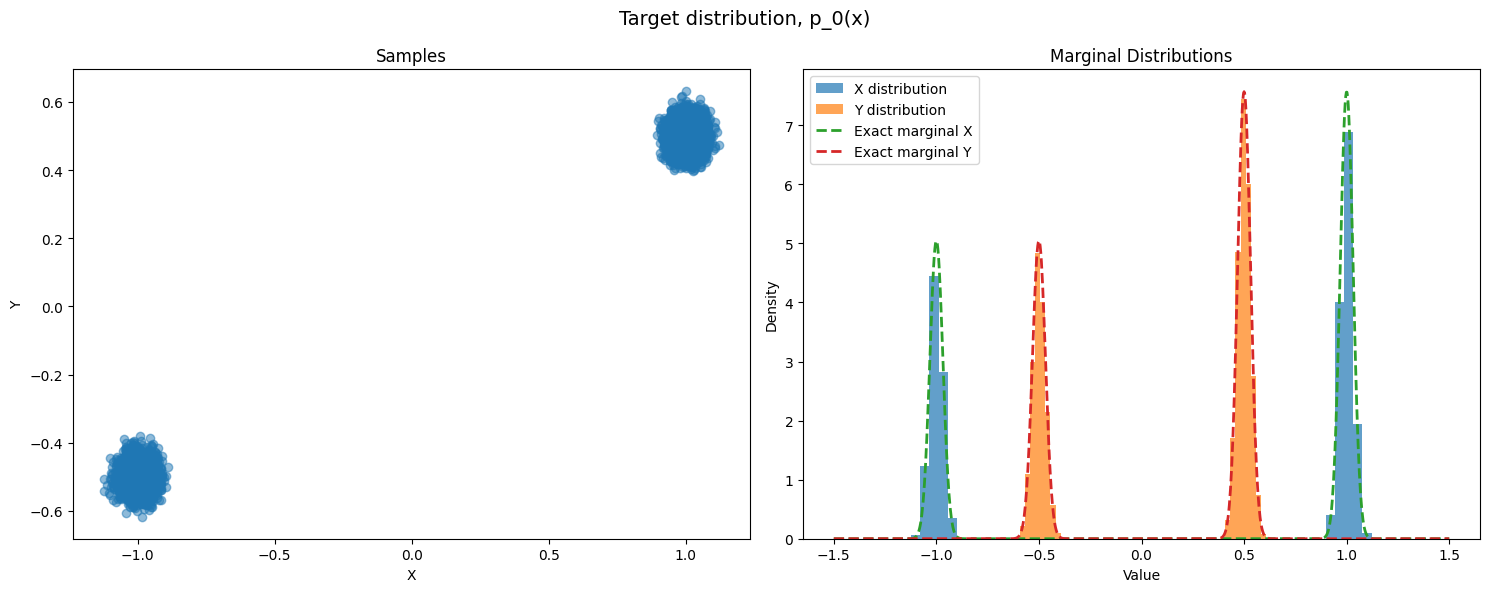

In [4]:
# Plot samples and marginal distributions
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Target distribution, p_0(x)', fontsize=14)

# First subplot: Scatter plot of samples
ax1.scatter(samples_target[:, 0], samples_target[:, 1], alpha=0.5)
ax1.set_title('Samples')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')

# Second subplot: Combined marginal distributions
ax2.hist(samples_target[:, 0], bins=50, density=True, alpha=0.7, label='X distribution')
ax2.hist(samples_target[:, 1], bins=50, density=True, alpha=0.7, label='Y distribution')

# Add exact marginal Gaussians
x = jnp.linspace(-1.5, 1.5, 1000)
for dim in range(2):
    marginal = jnp.zeros_like(x)
    for w, m, c in zip(weights, means, covs):
        mean = m[dim]
        std = jnp.sqrt(c[dim, dim])
        marginal += w * jnp.exp(-0.5 * ((x - mean) / std) ** 2) / (std * jnp.sqrt(2 * jnp.pi))
    ax2.plot(x, marginal, '--', linewidth=2, label=f'Exact marginal {["X", "Y"][dim]}')

ax2.set_title('Marginal Distributions')
ax2.set_xlabel('Value')
ax2.set_ylabel('Density')
ax2.legend()

plt.tight_layout()
plt.show()

# Physical system

## Network size and topology and temperature

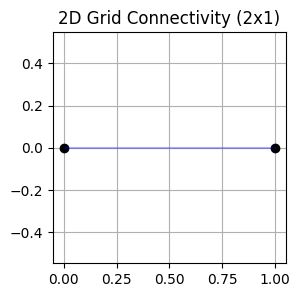

In [5]:
Temp = 0.1
N_osc = 2
connectivity = jnp.array([[0, 1]])
num_connections = connectivity.shape[0]
visualize_connectivity(connectivity,grid_size_x=2,grid_size_y=1)

## Energy

In [6]:
k_lin_0 = -1.*jnp.ones(N_osc)
k_duff_0 = jnp.ones(N_osc)
k_6_0 = jnp.ones(N_osc)
c_lin_0 = jnp.zeros(num_connections)
c_optomech_0 = jnp.zeros(num_connections)
c_duff_0 = jnp.zeros(num_connections)
biases_0 = jnp.zeros(N_osc)
params_initial = (k_lin_0, k_duff_0, k_6_0, c_lin_0, c_optomech_0, c_duff_0, biases_0)
params_names = ['k_lin', 'k_duff', 'k_6', 'c_lin', 'c_optomech', 'c_duff', 'biases']
params_flattened_initial, unflatten = flatten_util.ravel_pytree(params_initial)
constraint_indices_k6_self = jnp.arange(2*N_osc,3*N_osc)
constraint_indices = constraint_indices_k6_self

# Set up energy fn
energy_fn = setup_energy_fn(connectivity, unflatten)


### Plot initial energy landscape

Initial Parameters probability distribution total (should be ≈ 1): 1.000000


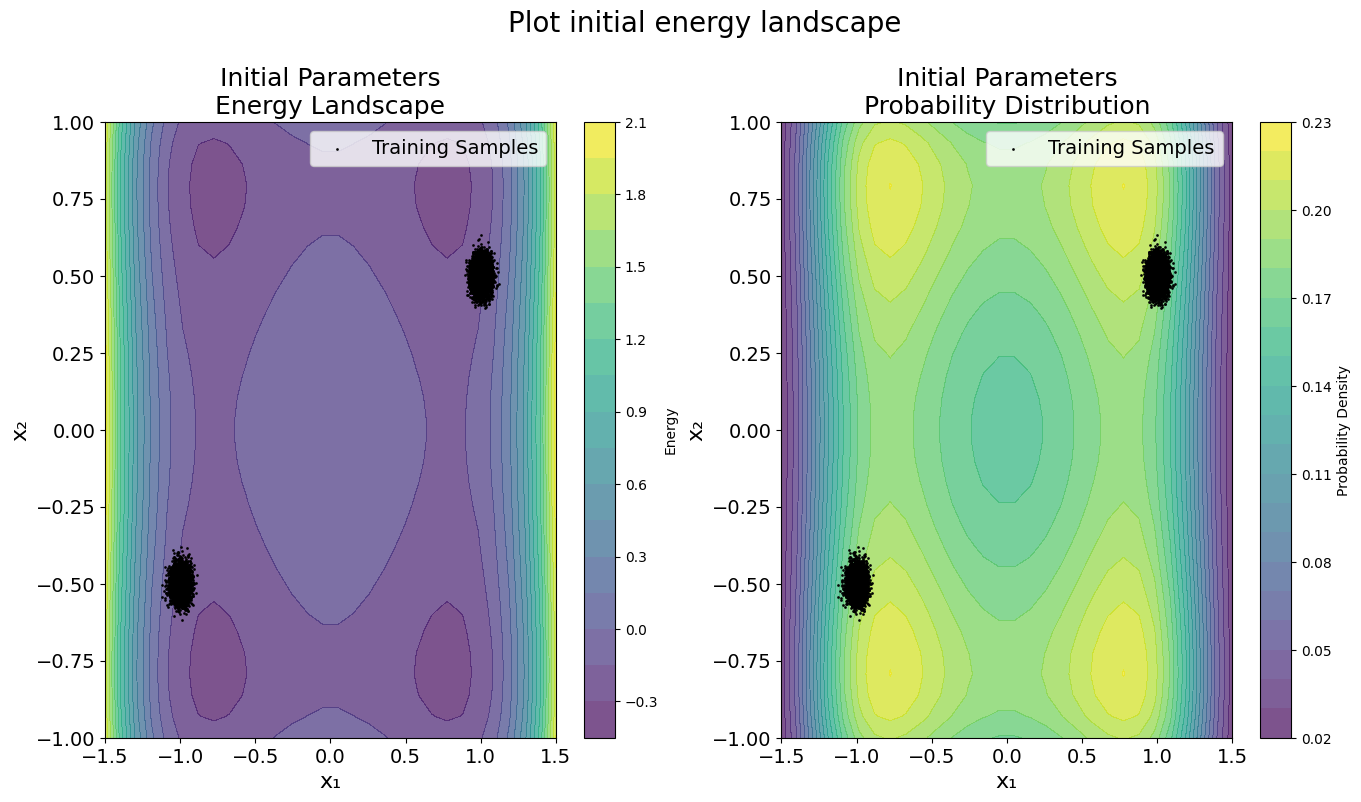

In [7]:
# Example usage:
param_list = [params_flattened_initial]
titles = ["Initial Parameters"]

plot_energy_and_distributions(
    energy_fn=energy_fn,
    param_list=param_list,
    samples=samples_target,
    x1_range=(-1.5, 1.5),   
    x2_range=(-1, 1),   
    n_points=30,       
    titles=titles,      
    figsize=(16, 8),   
    fontsize=16,        
    sample_stride=1,
    suptitle="Plot initial energy landscape" 
)

# Testing Gradients

### Auto-grad ground truth

In [8]:
loss_fn_per_batch_original= setup_score_matching_LOSS_per_batch(energy_fn, k_b=1.0, T=Temp)
auto_grad_truth = grad(loss_fn_per_batch_original)(params_flattened_initial,samples_target)

### Local learning rule (force matching) building full tensors (NOT memory efficient)

In [9]:
force_matching_gradient_fn_per_batch_using_AD = setup_force_matching_GRADIENT_per_batch_using_AD(energy_fn, k_b=1.0, T=Temp)

error_force_matching_gradient_using_AD = jnp.linalg.norm(auto_grad_truth - force_matching_gradient_fn_per_batch_using_AD(params_flattened_initial,samples_target))

print("The error of the local learning rule (force matching) building full tensors is", error_force_matching_gradient_using_AD)

The error of the local learning rule (force matching) building full tensors is 1.0486525172229791e-13


### Analytical gradient computation

In [10]:
# Set up analytical derivatives
gradient_fn, trace_hessian_fn, gradient_wrt_params_fn, trace_hessian_wrt_params_fn = setup_duffing_network_analytical_derivatives(connectivity, unflatten)
# Analytical force matching gradient
_, force_matching_gradient_fn_per_batch_analytical = setup_force_matching_LOSS_and_GRADIENT_per_batch_analytical(
    gradient_fn, trace_hessian_fn, gradient_wrt_params_fn, trace_hessian_wrt_params_fn, 
    k_b=1.0, T=Temp
)
error_force_matching_gradient_analytical = jnp.linalg.norm(auto_grad_truth - force_matching_gradient_fn_per_batch_analytical(params_flattened_initial,samples_target))

print("The error of the local learning rule (force matching) using analytical derivatives is", error_force_matching_gradient_analytical)

The error of the local learning rule (force matching) using analytical derivatives is 9.91781559981874e-14


### Memory efficient version

In [11]:
gradient_fn_memory_effcient, trace_hessian_fn_memory_effcient, _, _ = setup_duffing_network_analytical_derivatives_memory_efficient(connectivity, unflatten)
_, gradient_fn_per_batch_memory_efficient = setup_score_matching_kbT_loss_minimal_memory(
    gradient_fn_memory_effcient, trace_hessian_fn_memory_effcient, k_b=1.0, T=Temp
)
gradient_local_at_kbT_memory_efficient = gradient_fn_per_batch_memory_efficient(params_flattened_initial,samples_target)
error_local_at_kbT_memory_efficient = jnp.linalg.norm(auto_grad_truth - gradient_local_at_kbT_memory_efficient)
print("The error of the local learning rule (force matching) using memory efficient version is", error_local_at_kbT_memory_efficient)


The error of the local learning rule (force matching) using memory efficient version is 5.935592449242764e-13


### Test the CD1 gradient via a Hockey Stick Test

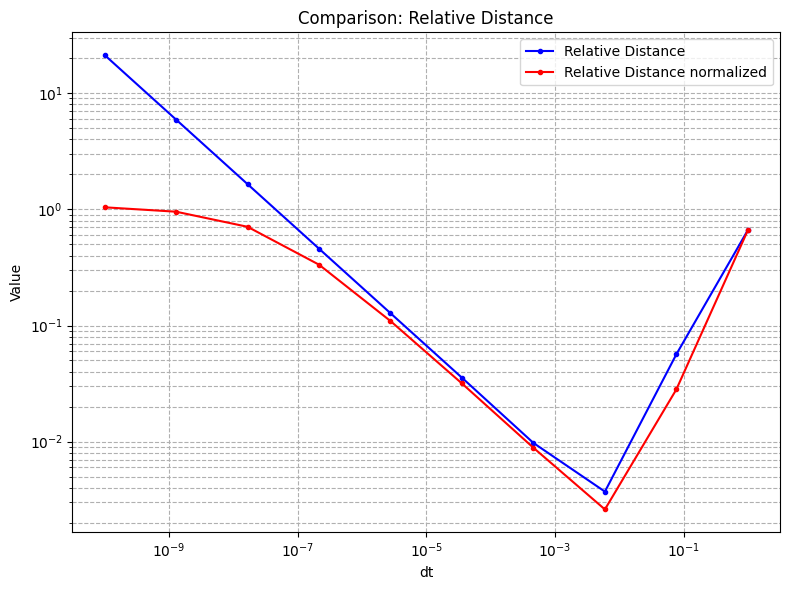

Minimum relative distance: 3.72e-03
dt at minimum: 5.99e-03


In [12]:
# Create a range of dt values on a log scale
dt_values = jnp.logspace(-10, 0, 10)  # 20 points from 1e-7 to 0.1

# Initialize arrays to store results
relative_distances = []
relative_distances_norm = []

# Loop over dt values
for dt in dt_values:
    
    # Compute CD1 gradient with current dt
    grad_CD1 = -CD1_gradient(energy_fn, samples_target, params_flattened_initial, dt=dt, D=Temp, key=jax.random.PRNGKey(1535), num_noise_samples=1000)
    
    # Compute relative distance between gradients
    grad_diff_norm = auto_grad_truth/jnp.linalg.norm(auto_grad_truth) - grad_CD1/jnp.linalg.norm(grad_CD1)
    relative_distance_norm = jnp.linalg.norm(grad_diff_norm) 
    
    grad_diff = auto_grad_truth - grad_CD1
    relative_distance = jnp.linalg.norm(grad_diff) / (jnp.linalg.norm(auto_grad_truth))
    
    # Store results
    relative_distances.append(relative_distance)
    relative_distances_norm.append(jnp.linalg.norm(relative_distance_norm))

# Convert to numpy arrays for plotting
relative_distances = jnp.array(relative_distances)
relative_distances_norm = jnp.array(relative_distances_norm)

plt.figure(figsize=(8, 6))

# Plot both on log-log scale
plt.loglog(dt_values, relative_distances, 'b.-', label='Relative Distance')
plt.loglog(dt_values, relative_distances_norm, 'r.-', label='Relative Distance normalized')

plt.xlabel('dt')
plt.ylabel('Value')
plt.title('Comparison: Relative Distance')
plt.grid(True, which="both", ls="--")
plt.legend()

plt.tight_layout()
plt.show()

# Print statistics
print(f"Minimum relative distance: {jnp.min(relative_distances):.2e}")
print(f"dt at minimum: {dt_values[jnp.argmin(relative_distances)]:.2e}")